transaction_date     object
transaction_month     int64
transaction_day       int64
transaction_hour      int64
dtype: object
Mean absolute errror: 8.40930
Mean squared errror: 189.80520
Root mean squared errror: 13.77698
R2 score: 0.32267


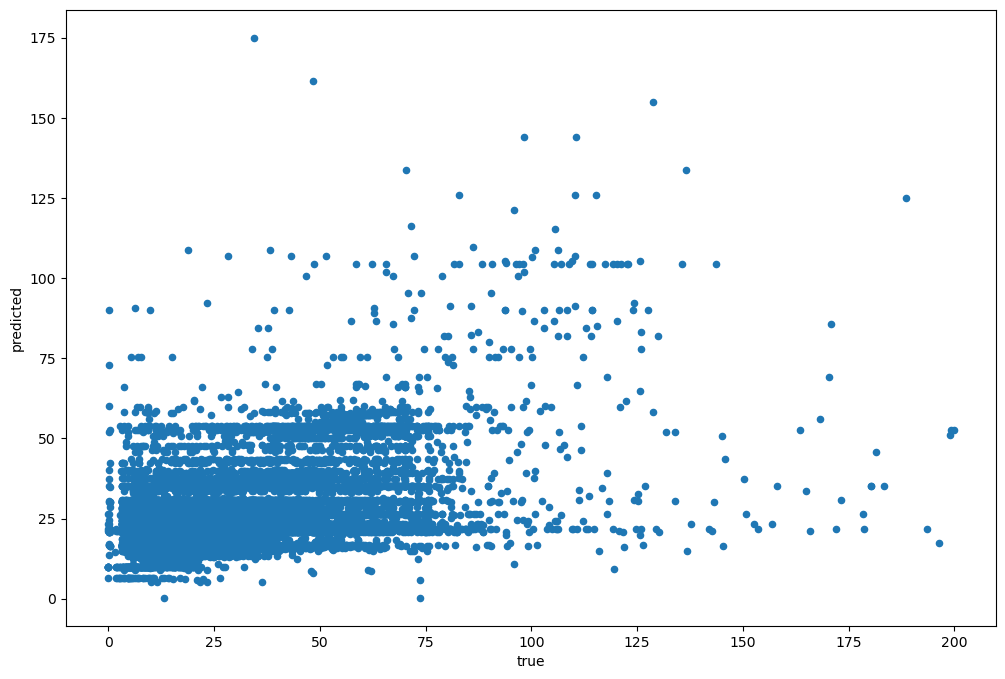

In [20]:
# start coding from here - load grouped data file size 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

taxi_grouped_by_region = pd.read_csv('data/taxi_grouped.csv')
taxi_grouped_by_region = taxi_grouped_by_region.drop(labels='Unnamed: 0', axis=1)

print(taxi_grouped_by_region[['transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']].dtypes)
data_for_benchmark_model = taxi_grouped_by_region.copy()

categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = ['total_amount']

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]
X_bench.dtypes

# one-hot encode
X_bench = pd.get_dummies(X_bench)

# split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# fit a model
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

# model evaluation
model_at_hand = tree
y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

print(f'Mean absolute errror: {mean_absolute_error(y_test_b, y_pred_b):.5f}')
print(f'Mean squared errror: {mean_squared_error(y_test_b, y_pred_b):.5f}')
print(f'Root mean squared errror: {sqrt(mean_squared_error(y_test_b, y_pred_b)):.5f}')
print(f'R2 score: {r2_score(y_test_b, y_pred_b):.5f}')

data = {'true': y_test_b.iloc[:, 0], 'predicted': y_pred_b}
# test: DataFrame - predicted: numpy array

results = pd.DataFrame(data)
results.plot(kind='scatter', x='true', y='predicted', figsize=(12, 8))
plt.show()



# 6 Data engineering

In [21]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


In [22]:
data_with_new_features = taxi_grouped_by_region.copy()

Data related features

In [23]:
data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date'])
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday

print(f'Here the week starts from 0 which is Monday')
print(data_with_new_features['transaction_week_day'].value_counts().index)
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 | x == 6 else False)

Here the week starts from 0 which is Monday
Index([2, 3, 1, 4, 0, 5, 6], dtype='int32', name='transaction_week_day')


In [24]:
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date

# transforming numpy array of objects to theDataTime format
holidays = pd.to_datetime(holidays)

data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True


Borough information

In [25]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
# zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)

print(f'{zone_lookup.dtypes}')
print(f"PULocationID_type: {data_with_new_features['PULocationID'].dtype}")

LocationID     int64
Borough       object
dtype: object
PULocationID_type: int64


In [26]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features = data_with_new_features.drop(labels='LocationID', axis=1)
print(data_with_new_features.shape)
data_with_new_features.head()

(102556, 12)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [27]:
print(data_with_new_features.isna().sum())
data_with_new_features['Borough'].value_counts()

PULocationID               0
transaction_date           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                  709
dtype: int64


Borough
Manhattan        45309
Brooklyn         23633
Queens           22002
Bronx             9586
Unknown            744
Staten Island      302
EWR                271
Name: count, dtype: int64

Weather related features

In [28]:
import requests
import pandas as pd

params = {
    'latitude': 40.7128,
    'longitude': -74.0060,
    'start_date': '2019-01-01',
    'end_date': '2019-01-31',
    'hourly': 'temperature_2m,relative_humidity_2m,cloudcover,windspeed_10m,precipitation',
    'timezone': 'America/New_York'
}

response = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params)

print(response.json().keys())
print(response.json()['hourly'].keys())

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data['hourly'], columns=['time', 'temperature_2m', 'relative_humidity_2m', 'windspeed_10m', 'cloudcover', 'precipitation'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df_3H = df.resample('3h').agg({
        'temperature_2m': 'mean', 
        'relative_humidity_2m': 'mean', 
        'windspeed_10m': 'mean', 
        'cloudcover': 'mean', 
        'precipitation': 'sum'
    })

    df_3H.to_csv('data/nyc_weather_no_missing values.csv')
    print(f'\nWeather data file saved correctly - status code: {response.status_code}')

else:
    print(f'\nSomething went wrong - status code: {response.status_code}')

df_3H.head()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'cloudcover', 'windspeed_10m', 'precipitation'])

Weather data file saved correctly - status code: 200


,temperature_2m,relative_humidity_2m,windspeed_10m,cloudcover,precipitation
time,,,,,
2019-01-01 00:00:00,8.700000,97.000000,16.100000,100.000000,7.1
2019-01-01 03:00:00,12.366667,94.333333,26.600000,99.000000,0.4
2019-01-01 06:00:00,13.600000,90.000000,29.633333,86.666667,0.0
2019-01-01 09:00:00,13.933333,74.333333,32.400000,99.000000,0.0
2019-01-01 12:00:00,11.500000,60.333333,33.400000,75.666667,0.0


In [29]:
index = pd.date_range('1/1/2000', periods=9, freq='h')
series = pd.Series(range(9), index=index)
print(series)

series.resample('3h').agg('sum')

2000-01-01 00:00:00    0
2000-01-01 01:00:00    1
2000-01-01 02:00:00    2
2000-01-01 03:00:00    3
2000-01-01 04:00:00    4
2000-01-01 05:00:00    5
2000-01-01 06:00:00    6
2000-01-01 07:00:00    7
2000-01-01 08:00:00    8
Freq: h, dtype: int64


2000-01-01 00:00:00     3
2000-01-01 03:00:00    12
2000-01-01 06:00:00    21
Freq: 3h, dtype: int64

In [37]:
# The source file has been modified to present how to deal with missing values, strings, etc
nyc_weather = pd.read_csv('data/nyc_weather_missing_values.csv')

# if there are NaN values at the beggining or end of DataFrame it would be not possible to use .interpolate()
# use .fillna(method='ffill', 'bfill') instead
nyc_weather.head()
nyc_weather.tail()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
243,2019-01-31 09:00:00,-14.600000,35.333333,20.766667,no clouds,NaN
244,2019-01-31 12:00:00,-10.333333,26.666667,19.566667,no clouds,0.0
245,2019-01-31 15:00:00,-8.566667,25.666667,20.700000,no clouds,NaN
246,2019-01-31 18:00:00,-9.966667,32.666667,17.100000,no clouds,NaN
247,2019-01-31 21:00:00,-10.433333,31.333333,14.600000,no clouds,0.0


In [31]:
nyc_weather['cloud cover'].value_counts()

cloud cover
100%.           99
no clouds       55
70 – 80%.       36
20–30%.         28
50%.            22
??               1
weird_value1     1
undefined        1
broken_data      1
Name: count, dtype: int64

In [32]:
nyc_weather['amount of precipitation'].value_counts()

amount of precipitation
0.0                       125
Trace of precipitation     17
0.1                         6
0.4                         3
1.6                         2
0.2                         2
0.3                         2
7.1                         1
1.0                         1
1.9                         1
0.5                         1
10.3                        1
9.0                         1
5.7                         1
5.2                         1
0.8                         1
8.899999999999999           1
8.4                         1
3.0                         1
2.9                         1
1.8                         1
3.2                         1
6.4                         1
2.6                         1
Name: count, dtype: int64

In [33]:
nyc_weather.isna().sum()

date and time               0
temperature                 0
humidity                    0
wind speed                  0
cloud cover                 4
amount of precipitation    74
dtype: int64

Trace of precipitation can be thought of as 0.1\
And the missing values 0 ???\
to be considered

In [34]:
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].replace('Trace of precipitation', 0.1)
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'] .astype(float)

# Dealing with the missing values

# option 1
# nyc_weather['amount of precipitation'].fillna(0, inplace=True)

# option 2
# nyc_weather['amount of precipitation'].fillna(method='bfill', inplace=True)

# option 3
nyc_weather['amount of precipitation'].interpolate(inplace=True)

C:\Users\a\AppData\Local\Temp\ipykernel_6436\3028843784.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nyc_weather['amount of precipitation'].interpolate(inplace=True)


In [35]:
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('100%.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('no clouds', 0)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('70 – 80%.', 0.8)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('20–30%.', 0.3)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('50%.', 0.5)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('Sky obscured by fog and/or other meteorological phenomena.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].astype(float)

nyc_weather['cloud cover'].interpolate(inplace=True)

ValueError: could not convert string to float: '??'

In [ ]:
nyc_weather.head()

In [ ]:
data_with_new_features.head()
nyc_weather['date and time'] = pd.to_datetime(nyc_weather['date and time'])

nyc_weather['month'] = nyc_weather['date and time'].dt.month
nyc_weather['day'] = nyc_weather['date and time'].dt.day
nyc_weather['hour'] = nyc_weather['date and time'].dt.hour

nyc_weather.head(1)

In [ ]:
data_with_new_features.head(1)

In [ ]:
data_with_new_features = data_with_new_features.merge(nyc_weather, 
left_on=['transaction_month','transaction_day','transaction_hour'], 
right_on=['month','day','hour'],
how='left')
data_with_new_features = data_with_new_features.drop(columns=['date and time', 'month','day','hour'])

print(data_with_new_features.shape)
data_with_new_features.head(2)

In [ ]:
data_with_new_features.isna().sum()

In [ ]:
data_with_new_features.head()
# data_with_new_features.tail()